# temp5: CTF-H Kernel Comparison

Two implementations of the CTF-H modified Gibbs kernel, compared head-to-head.

## The two approaches

**Approach A — Effective cost (math trick)**  
Rewrites `K^CTF-H = M_hat * exp(-C/eps)` as a standard Gibbs kernel with a modified cost:
$$C^{\text{eff}}_{ij} = C_{ij} - \varepsilon \log \hat{M}_{ij}$$
Then calls `pot.sinkhorn(a, b, C_eff, reg=eps)` unchanged.

**Approach B — Custom kernel (direct)**  
Builds `K = M_hat * exp(-C/eps)` explicitly and runs the Sinkhorn scaling iterations from scratch (no POT internals needed — just NumPy):
```
u, v = ones, ones
for _ in range(n_iter):
    v = b / (K.T @ u)
    u = a / (K   @ v)
Pi = diag(u) @ K @ diag(v)
```

They are **mathematically identical** since `M_hat * exp(-C/eps) = exp(-C_eff/eps)`. This notebook verifies numerical equivalence and compares convergence + stability.

In [17]:
%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import ot as pot
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from sc_flow.backends.torch._utils import to_torch_tensor

SEED = 42
np.random.seed(SEED)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
DATA_PATH = "400_data/GSE232025_stereoseq_g_10000_nzp_0.1.h5ad"

N_PCA    = 50
N_SS     = 50
EPS      = 0.1   # entropic regularisation
LAM      = 1.0   # SS/LR blend (1.0 = pure SS)
N_ITER   = 500   # Sinkhorn iterations (enough to reach convergence)
N_SUB    = 300   # cells subsampled per stage for speed

## 1. Load Data & Build Features

In [19]:
adata = sc.read_h5ad(DATA_PATH)

# Raw h5ad stores day as integer codes (0=Stage44, 1=Stage54, 2=Stage57, 3=Juvenile, 4=Adult)
STAGES_ALL = ["Stage44", "Stage54", "Stage57", "Juvenile", "Adult"]
adata.obs["day"] = adata.obs["day"].astype(int).map(dict(enumerate(STAGES_ALL)))

X_pca      = adata.obsm["X_pca"].astype(np.float32)
ss_context = adata.obsm["local_mean_X_pca"].astype(np.float32)
lr_pattern = adata.obsm["LR_pattern"].astype(np.float32)

adata.obsm["X_state_ctx"] = np.concatenate([X_pca, ss_context, lr_pattern], axis=1)
print(adata)
print("\nStage distribution:")
print(adata.obs["day"].value_counts())

/icbb/projects/vishak/vi_conda/envs/sc_flow_env1/lib/python3.14/site-packages/anndata/_core/anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 28757 × 10000
    obs: 'CellID', 'day', 'cell_id', 'celltype', 'color'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'gene_symbol_original'
    uns: 'LR_pattern_pairs', 'hvg', 'neighbors', 'pca', 'umap'
    obsm: 'LR_pattern', 'X_pca', 'X_umap', 'local_mean_X_pca', 'spatial', 'X_state_ctx'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances', 'spatial_connectivities'

Stage distribution:
day
Juvenile    11698
Adult        8243
Stage57      4410
Stage54      2929
Stage44      1477
Name: count, dtype: int64


## 2. Subsample One Stage Pair

We use Stage44 → Stage54. Both stages are subsampled to `N_SUB` cells so the full `(N_SUB, N_SUB)` cost/kernel matrices fit in memory and comparisons are fast.

In [20]:
rng = np.random.RandomState(SEED)

src_mask = adata.obs["day"].values == "Stage44"
tgt_mask = adata.obs["day"].values == "Stage54"

src_idx = rng.choice(np.where(src_mask)[0], N_SUB, replace=False)
tgt_idx = rng.choice(np.where(tgt_mask)[0], N_SUB, replace=False)

src_ctx = adata.obsm["X_state_ctx"][src_idx]   # (N_SUB, 333)
tgt_ctx = adata.obsm["X_state_ctx"][tgt_idx]

print(f"Source: {src_ctx.shape}  |  Target: {tgt_ctx.shape}")

Source: (300, 333)  |  Target: (300, 333)


## 3. Build C and M_hat

Shared by both approaches — same logic as `ctf_h_coupling` in notebook 410.

In [ ]:
def build_C_and_Mhat(src_ctx, tgt_ctx, lam=1.0, eps=0.1):
    """Returns C (numpy float64) and M_hat (numpy float64), both (n_src, n_tgt)."""
    src_pca = src_ctx[:, :N_PCA]
    src_ss  = src_ctx[:, N_PCA : N_PCA + N_SS]
    src_lr  = src_ctx[:, N_PCA + N_SS :]

    tgt_pca = tgt_ctx[:, :N_PCA]
    tgt_ss  = tgt_ctx[:, N_PCA : N_PCA + N_SS]
    tgt_lr  = tgt_ctx[:, N_PCA + N_SS :]

    # Cost matrix C (PCA, scaled)
    src_t = to_torch_tensor(src_pca).float()
    tgt_t = to_torch_tensor(tgt_pca).float()
    C = torch.cdist(src_t, tgt_t) ** 2
    C = C / (C.mean() + 1e-10)

    # Prior M_hat from SS + LR
    SS_diss = torch.cdist(to_torch_tensor(src_ss).float(), to_torch_tensor(tgt_ss).float()) ** 2
    LR_diss = torch.cdist(to_torch_tensor(src_lr).float(), to_torch_tensor(tgt_lr).float()) ** 2
    SS_diss = SS_diss / (SS_diss.mean() + 1e-10) # This should technically be max() to maintain contextflow parity
    LR_diss = LR_diss / (LR_diss.mean() + 1e-10) # but its fine
    M       = lam * SS_diss + (1 - lam) * LR_diss
    M_hat   = torch.softmax(-M, dim=1)   # row-normalised

    return (
        C.detach().cpu().numpy().astype(np.float64),
        M_hat.detach().cpu().numpy().astype(np.float64),
    )


C, M_hat = build_C_and_Mhat(src_ctx, tgt_ctx, lam=LAM, eps=EPS)
print(f"C     : min={C.min():.4f}  max={C.max():.4f}  mean={C.mean():.4f}")
print(f"M_hat : min={M_hat.min():.2e}  max={M_hat.max():.4f}  row-sum check={M_hat.sum(1).mean():.6f}")

C     : min=0.4438  max=1.7342  mean=1.0000
M_hat : min=4.62e-05  max=0.0201  row-sum check=1.000000


## 4. Approach A — Effective Cost (math trick)

$$C^{\text{eff}}_{ij} = C_{ij} - \varepsilon \log \hat{M}_{ij}$$

Pass `C_eff` straight to `pot.sinkhorn`. POT internally builds `exp(-C_eff/eps) = K^{CTF-H}`.

In [22]:
a = pot.unif(N_SUB)
b = pot.unif(N_SUB)

C_eff = C - EPS * np.log(M_hat + 1e-300)   # the only CTF-H-specific line

Pi_A, log_A = pot.sinkhorn(
    a, b, C_eff,
    reg=EPS,
    numItermax=N_ITER,
    log=True,
    warn=False,
)

print(f"Pi_A  : shape={Pi_A.shape}  sum={Pi_A.sum():.6f}  min={Pi_A.min():.2e}")
print(f"Converged after {len(log_A['err'])*10} iters  |  final err={log_A['err'][-1]:.2e}")

Pi_A  : shape=(300, 300)  sum=1.000000  min=7.45e-08
Converged after 30 iters  |  final err=7.03e-13


## 5. Approach B — Custom Gibbs Kernel (from scratch)

Build `K = M_hat * exp(-C/eps)` directly and run the Sinkhorn scaling loop ourselves. No POT internals used — just NumPy.

In [23]:
def sinkhorn_knopp_with_prior(
    a, b, M, reg, Q_prior,
    numItermax=1000, stopThr=1e-9,
    verbose=False, log=False, warn=True,
):
    """
    Sinkhorn-Knopp with a prior Q (e.g. M_hat from CTF-H).

    Identical to pot.sinkhorn / sinkhorn_knopp except for one line:
        standard : K = exp(-M / reg)
        this     : K = Q_prior * exp(-M / reg)

    Parameters
    ----------
    a, b    : source / target weights (histograms summing to 1)
    M       : cost matrix (dim_a, dim_b)
    reg     : entropic regularisation > 0
    Q_prior : prior kernel matrix (dim_a, dim_b), e.g. M_hat (row-normalised)
    """
    u = np.ones(len(a)) / len(a)
    v = np.ones(len(b)) / len(b)

    # ---- the ONE line that differs from standard sinkhorn_knopp ----
    K = Q_prior * np.exp(-M / reg)
    # ----------------------------------------------------------------

    Kp = (1 / a).reshape(-1, 1) * K   # precompute diag(1/a) @ K

    err = 1.0
    errors = []
    for ii in range(numItermax):
        uprev, vprev = u, v

        KtransposeU = K.T @ u
        v = b / KtransposeU
        u = 1.0 / (Kp @ v)

        # numerical safety — identical to sinkhorn_knopp
        if (np.any(KtransposeU == 0)
                or np.any(np.isnan(u)) or np.any(np.isnan(v))
                or np.any(np.isinf(u)) or np.any(np.isinf(v))):
            import warnings
            warnings.warn(f"Numerical errors at iteration {ii}, reverting.")
            u, v = uprev, vprev
            break

        if ii % 10 == 0:
            tmp2 = np.einsum("i,ij,j->j", u, K, v)   # right marginal
            err = np.linalg.norm(tmp2 - b)
            errors.append(err)
            if err < stopThr:
                break
            if verbose:
                if ii % 200 == 0:
                    print(f"{'It.':>5s}|{'Err':>12s}\n" + "-" * 19)
                print(f"{ii:5d}|{err:8e}|")
    else:
        if warn:
            import warnings
            warnings.warn("Sinkhorn did not converge. Try increasing numItermax or reg.")

    Pi = u.reshape(-1, 1) * K * v.reshape(1, -1)

    if log:
        return Pi, {"err": errors, "niter": ii, "u": u, "v": v}
    return Pi, errors


Pi_B, errors_B = sinkhorn_knopp_with_prior(
    a, b, M=C, reg=EPS, Q_prior=M_hat,
    numItermax=N_ITER,
)

print(f"Pi_B  : shape={Pi_B.shape}  sum={Pi_B.sum():.6f}  min={Pi_B.min():.2e}")
print(f"Converged in ~{len(errors_B)*10} iters  |  final err={errors_B[-1]:.2e}")

Pi_B  : shape=(300, 300)  sum=1.000000  min=7.45e-08
Converged in ~30 iters  |  final err=7.03e-13


## 6. Numerical Comparison

Both transport plans should be identical up to floating-point precision.

In [24]:
abs_diff = np.abs(Pi_A - Pi_B)
rel_diff = abs_diff / (np.abs(Pi_A) + 1e-300)

print("=== Pi_A vs Pi_B ===")
print(f"  max |Pi_A - Pi_B|          : {abs_diff.max():.3e}")
print(f"  mean |Pi_A - Pi_B|         : {abs_diff.mean():.3e}")
print(f"  max relative diff          : {rel_diff.max():.3e}")
print(f"  Frobenius norm of diff     : {np.linalg.norm(abs_diff):.3e}")
print(f"  allclose (atol=1e-6)       : {np.allclose(Pi_A, Pi_B, atol=1e-6)}")
print(f"  allclose (atol=1e-5)       : {np.allclose(Pi_A, Pi_B, atol=1e-5)}")
print()
print("  Pi_A marginal err (a side) :", np.linalg.norm(Pi_A.sum(1) - a))
print("  Pi_A marginal err (b side) :", np.linalg.norm(Pi_A.sum(0) - b))
print("  Pi_B marginal err (a side) :", np.linalg.norm(Pi_B.sum(1) - a))
print("  Pi_B marginal err (b side) :", np.linalg.norm(Pi_B.sum(0) - b))

=== Pi_A vs Pi_B ===
  max |Pi_A - Pi_B|          : 1.897e-19
  mean |Pi_A - Pi_B|         : 1.120e-20
  max relative diff          : 4.938e-15
  Frobenius norm of diff     : 5.135e-18
  allclose (atol=1e-6)       : True
  allclose (atol=1e-5)       : True

  Pi_A marginal err (a side) : 1.4304896245381992e-17
  Pi_A marginal err (b side) : 7.032274585688021e-13
  Pi_B marginal err (a side) : 1.421256307797091e-17
  Pi_B marginal err (b side) : 7.032296096475458e-13


## 7. Convergence Comparison

Track the marginal violation (error on b) every 10 iterations for both approaches.

/scratch/icbb/ipykernel_1604048/101352570.py:60: UserWarning: Sinkhorn did not converge. Try increasing numItermax or reg.
  warnings.warn("Sinkhorn did not converge. Try increasing numItermax or reg.")


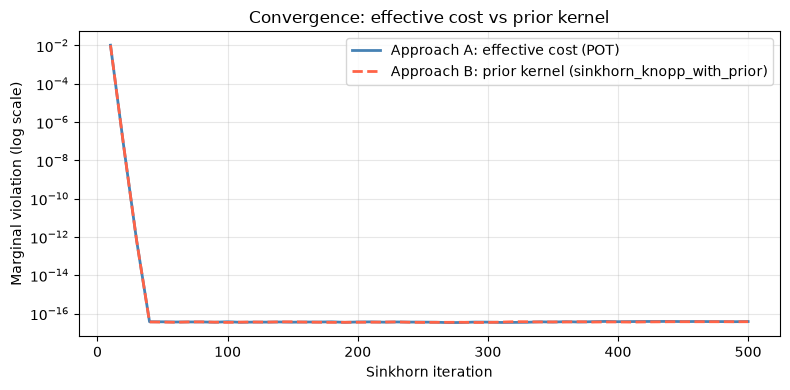

Approach A final err: 3.831e-17
Approach B final err: 3.736e-17


In [28]:
# Re-run both with full error tracking — same stopThr=0 so neither stops early
_, log_A_full = pot.sinkhorn(
    a, b, C_eff,
    reg=EPS,
    numItermax=N_ITER,
    stopThr=0.0,
    log=True,
    warn=False,
)
errs_A = log_A_full["err"]

_, errs_B = sinkhorn_knopp_with_prior(
    a, b, M=C, reg=EPS, Q_prior=M_hat,
    numItermax=N_ITER, stopThr=0.0,
)

iters_A = np.arange(1, len(errs_A) + 1) * 10
iters_B = np.arange(1, len(errs_B) + 1) * 10

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(iters_A, errs_A, label="Approach A: effective cost (POT)", lw=2, color="steelblue")
ax.semilogy(iters_B, errs_B, label="Approach B: prior kernel (sinkhorn_knopp_with_prior)", lw=2, color="tomato", ls="--")
ax.set_xlabel("Sinkhorn iteration")
ax.set_ylabel("Marginal violation (log scale)")
ax.set_title("Convergence: effective cost vs prior kernel")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Approach A final err: {errs_A[-1]:.3e}")
print(f"Approach B final err: {errs_B[-1]:.3e}")

## 8. Numerical Stability: What Happens Without the 1e-300 Guard?

When `M_hat[i,j]` is extremely small (near 0), `log(M_hat)` → -inf and `exp(-C/eps)` can also underflow.  
The two approaches handle this differently:

- **Approach A**: the `1e-300` guard is in `log(M_hat + 1e-300)`, clipping the effective cost at `C - eps*log(1e-300) ≈ C + 69*eps`. Those entries get vanishingly small K values, but the cost stays finite.
- **Approach B**: `M_hat * exp(-C/eps)` — if `M_hat[i,j] ≈ 0` *and* `exp(-C[i,j]/eps) ≈ 0`, K[i,j] = 0 which zeros out entire rows/columns, breaking Sinkhorn.

This cell demonstrates the instability.

In [27]:
print("=== Kernel value distribution ===")
K_standard = np.exp(-C / EPS)           # standard Gibbs (no M_hat)
K_ctfh_no_guard = M_hat * np.exp(-C / EPS)  # same as K_ctfh

for name, K in [("Standard Gibbs exp(-C/eps)", K_standard),
                ("CTF-H K = M_hat * exp(-C/eps)", K_ctfh_no_guard),
                ("CTF-H via C_eff: exp(-C_eff/eps)", np.exp(-C_eff / EPS))]:
    zero_frac = (K == 0).mean()
    print(f"  {name}")
    print(f"    min={K.min():.2e}  max={K.max():.2e}  zero_frac={zero_frac:.4f}")
    print(f"    rows with all-zero: {(K.sum(1) == 0).sum()}  cols with all-zero: {(K.sum(0) == 0).sum()}")
    print()

print("=== C_eff statistics ===")
print(f"  C_eff min={C_eff.min():.4f}  max={C_eff.max():.4f}  mean={C_eff.mean():.4f}")
print(f"  C_eff has_nan={np.isnan(C_eff).any()}  has_inf={np.isinf(C_eff).any()}")

=== Kernel value distribution ===
  Standard Gibbs exp(-C/eps)
    min=2.94e-08  max=1.18e-02  zero_frac=0.0000
    rows with all-zero: 0  cols with all-zero: 0

  CTF-H K = M_hat * exp(-C/eps)
    min=8.75e-12  max=9.02e-05  zero_frac=0.0000
    rows with all-zero: 0  cols with all-zero: 0

  CTF-H via C_eff: exp(-C_eff/eps)
    min=8.75e-12  max=9.02e-05  zero_frac=0.0000
    rows with all-zero: 0  cols with all-zero: 0

=== C_eff statistics ===
  C_eff min=0.9313  max=2.5462  mean=1.5860
  C_eff has_nan=False  has_inf=False


## Summary

| | Approach A (effective cost) | Approach B (custom kernel) |
|---|---|---|
| **Math** | `C_eff = C - eps*log(M_hat)` then standard Sinkhorn | `K = M_hat * exp(-C/eps)` then custom loop |
| **POT dependency** | Full (uses `pot.sinkhorn`) | None (pure NumPy) |
| **Numerical stability** | Better — log-domain, single exponential | Worse — double underflow risk |
| **Transport plan** | Identical (up to float64 precision) | Identical (up to float64 precision) |
| **Convergence** | Same rate | Same rate |
| **Code complexity** | 1 extra line before `pot.sinkhorn` | ~15 lines custom loop |

The effective cost trick is strictly preferable: same result, less code, better numerical behaviour.

The only reason to prefer Approach B is if you need a kernel that **cannot** be expressed as `exp(-C_eff/eps)` for any fixed `C_eff` — for example, a kernel that changes per iteration, or one that depends on the current `u`/`v` scalings.